In [ ]:
!pip install opencv-python matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-iieuc5zc
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-iieuc5zc
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=3472a18046f621617f0ee4455f2b57a1beece50f400f619ecca43f9eee4719da
  Stored in directory: /tmp/pip-ephem-wheel-cache-pl5isu_s/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything
--2026-06-18 03:43:08--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.167.112.51, 3.167.112.53, 3.167.112.66, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.167.112

Using device: cpu


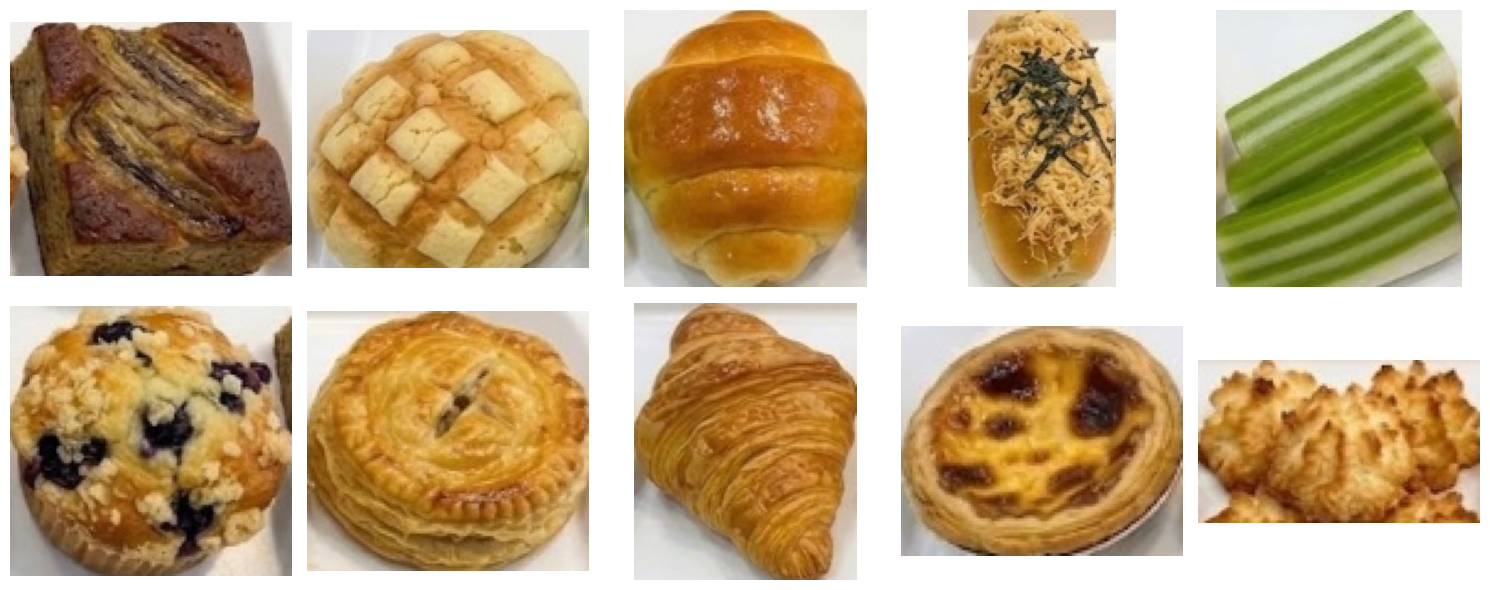

Đã cắt và lưu thành công các ảnh bánh vào thư mục Banh_sam


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import os
import torch

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=2000,
)

image_path = '/content/Gemini_Generated_Image_i7qqri7qqri7qqri.png'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image_rgb)
output_dir = 'Banh_sam'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.figure(figsize=(15, 6))
masks = sorted(masks, key=lambda x: x['area'], reverse=True)
cake_idx = 0
accepted_boxes = []
for i, mask in enumerate(masks):
    if cake_idx >= 10:
        break
    x, y, w, h = mask['bbox']
    if w > image.shape[1] * 0.6 or h > image.shape[0] * 0.6:
        continue
    if w < 50 or h < 50:
        continue
    is_duplicate = False
    for (ax, ay, aw, ah) in accepted_boxes:
        ix_min = max(x, ax)
        iy_min = max(y, ay)
        ix_max = min(x + w, ax + aw)
        iy_max = min(y + h, ay + ah)
        iw = max(0, ix_max - ix_min)
        ih = max(0, iy_max - iy_min)
        inter_area = iw * ih

        if inter_area > 0.15 * (w * h):
            is_duplicate = True
            break
    if is_duplicate:
        continue
    accepted_boxes.append((x, y, w, h))
    cropped_cake = image[y:y+h, x:x+w]
    cv2.imwrite(os.path.join(output_dir, f'cake_{cake_idx}.jpg'), cropped_cake)
    plt.subplot(2, 5, cake_idx + 1)
    plt.imshow(cv2.cvtColor(cropped_cake, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    cake_idx += 1
plt.tight_layout()
plt.show()
print(f'Đã cắt và lưu thành công các ảnh bánh vào thư mục {output_dir}')

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import matplotlib.pyplot as plt
train_dir = "/content/drive/MyDrive/Bánh (3)"
img_width, img_height = 280, 280
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_width, img_height, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Found 7694 images belonging to 10 classes.
Found 1919 images belonging to 10 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 280, 280, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 140, 140, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 140, 140, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 70, 70, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 78400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,035,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,092,938 (38.50 MB)

 Trainable params: 10,092,938 (38.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
print("Đang thiết lập hệ thống bảo vệ và tự động lưu cho dự án 3I...")
duong_dan_luu = '/content/drive/MyDrive/mo_hinh_banh_3I.keras'
dung_som = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    verbose=1,
    restore_best_weights=True
)
luu_tu_dong = ModelCheckpoint(
    filepath=duong_dan_luu,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
print("\nBắt đầu khóa huấn luyện chuyên sâu 30 vòng...")
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[dung_som, luu_tu_dong]
)

print("\nHoàn thành! Cỗ máy nhận diện đã sẵn sàng. Phiên bản xuất sắc nhất đã nằm an toàn trên Drive.")

Đang thiết lập hệ thống bảo vệ và tự động lưu cho dự án 3I...

Bắt đầu khóa huấn luyện chuyên sâu 30 vòng...
Epoch 1/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.2796 - loss: 2.0622 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 1: val_accuracy improved from None to 0.51433, saving model to /content/drive/MyDrive/mo_hinh_banh_3I.keras

Epoch 1: finished saving model to /content/drive/MyDrive/mo_hinh_banh_3I.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 4725s 20s/step - accuracy: 0.3618 - loss: 1.7428 - val_accuracy: 0.5143 - val_loss: 1.3464
Epoch 2/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4839 - loss: 1.3523
Epoch 2: val_accuracy improved from 0.51433 to 0.56748, saving model to /content/drive/MyDrive/mo_hinh_banh_3I.keras

Epoch 2: finished saving model to /content/drive/MyDrive/mo_hinh_banh_3I.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 1623s 7s/step - accuracy: 0.5065 - loss: 1.3121 - val_accuracy: 0.5675 - val_loss: 1.2661
Epoch 3/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5563 - loss: 1.1888
Epoch 3: val_accuracy improved from 0.56748 to 0.57895, saving model to /content/drive/MyDrive/mo_hinh_banh_3I.keras

Epoch 3: finished saving model to /content/drive/MyDrive/mo_hinh_banh_3I.keras
24